In [1]:
from rtmag.process.download.find_harp import find_ar
from rtmag.process.download.dl_map import get_sharp_map
from rtmag.process.paper.hmi_to_input import get_input

d = "2024-05-09 02:00:00"#データを指定
ar, img = find_ar(d, show_image=True)
harpnum = 11149
noaanum = ar[ar['HARPNUM'] == harpnum]['NOAA_AR'].item()
hmi_map, hmi_data = get_sharp_map(d, harpnum)
hmi_data.shape

nx = 512
ny = 256

model_input, x, y, z, dx, dy, dz = get_input(hmi_data, nx, ny)
model_input.shape




T_REC:  2024.05.09_02:00:00_TAI
http://jsoc.stanford.edu/SUM93/D1753918816/S00000/Bp.fits


URLError: <urlopen error _ssl.c:983: The handshake operation timed out>

Processing model: /workspaces/template_pytorch/rtmag-main/D:/models/lowlou_high_div/best_model.pt
Model loaded from epoch 10
b_norm = 200 G
cuda:0
0.7599594593048096 seconds
Processing model: /workspaces/template_pytorch/rtmag-main/D:/models/lowlou_high_ff/model_5.pt
Model loaded from epoch 5
b_norm = 200 G
cuda:0
0.18017077445983887 seconds
Processing model: /workspaces/template_pytorch/rtmag-main/D:/models/lowlou_low_div/best_model.pt
Model loaded from epoch 11
b_norm = 200 G
cuda:0
0.19100713729858398 seconds
Processing model: /workspaces/template_pytorch/rtmag-main/D:/models/lowlou_low_ff/model_5.pt
Model loaded from epoch 5
b_norm = 200 G
cuda:0
0.17585039138793945 seconds
Processing model: /workspaces/template_pytorch/rtmag-main/D:/models/lowlou_no_bc/model_5.pt
Model loaded from epoch 5
b_norm = 200 G
cuda:0
0.1754918098449707 seconds
Processing model: /workspaces/template_pytorch/rtmag-main/D:/models/lowlou_no_div/model_4.pt
Model loaded from epoch 4
b_norm = 200 G
cuda:0
0.176

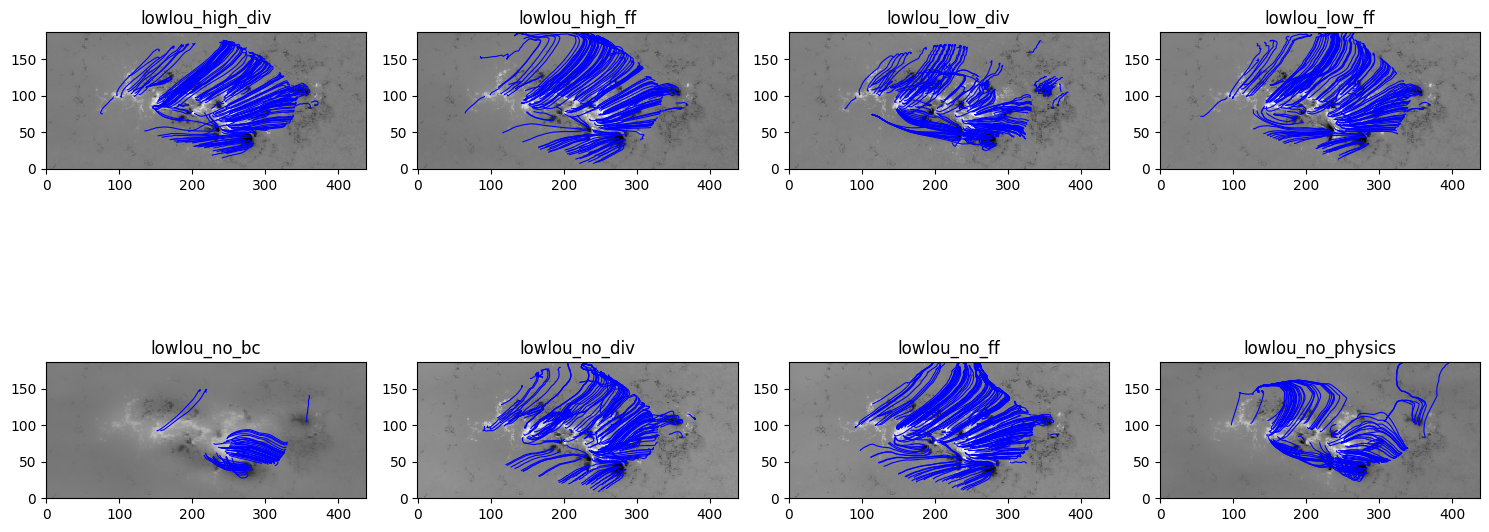

In [ ]:
import torch
from rtmag.process.paper.load import MyModel
import matplotlib.pyplot as plt
import numpy as np
from streamtracer import StreamTracer, VectorGrid
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# モデルパス一覧
paths = [
    "/workspaces/template_pytorch/rtmag-main/D:/models/lowlou_high_div/model_5.pt", 
    "/workspaces/template_pytorch/rtmag-main/D:/models/lowlou_high_ff/model_5.pt", 
    "/workspaces/template_pytorch/rtmag-main/D:/models/lowlou_low_div/best_model.pt",
    "/workspaces/template_pytorch/rtmag-main/D:/models/lowlou_low_ff/model_5.pt",
    "/workspaces/template_pytorch/rtmag-main/D:/models/lowlou_no_bc/model_5.pt",
    "/workspaces/template_pytorch/rtmag-main/D:/models/lowlou_no_div/model_4.pt",
    "/workspaces/template_pytorch/rtmag-main/D:/models/lowlou_no_ff/model_4.pt",
    "/workspaces/template_pytorch/rtmag-main/D:/models/lowlou_no_physics/model_4.pt"
]

paths = [
    "/workspaces/template_pytorch/rtmag-main/D:/models/lowlou_high_div/best_model.pt", 
    "/workspaces/template_pytorch/rtmag-main/D:/models/lowlou_high_ff/best_model.pt", 
    "/workspaces/template_pytorch/rtmag-main/D:/models/lowlou_low_div/best_model.pt",
    "/workspaces/template_pytorch/rtmag-main/D:/models/lowlou_low_ff/best_model.pt",
    "/workspaces/template_pytorch/rtmag-main/D:/models/lowlou_no_bc/best_model.pt",
    "/workspaces/template_pytorch/rtmag-main/D:/models/lowlou_no_div/best_model.pt",
    "/workspaces/template_pytorch/rtmag-main/D:/models/lowlou_no_ff/best_model.pt",
    "/workspaces/template_pytorch/rtmag-main/D:/models/lowlou_no_physics/best_model.pt"
]


# 描画に使うパラメータ
stride = 20
nsteps = 10000
step_size = 0.1
grid_spacing = [1, 1, 1]

results = [] 
b_array = []
 # まとめ出力用に保持

for idx, meta_path in enumerate(paths):
    print(f"Processing model: {meta_path}")
    mm = MyModel(meta_path, device=device)

    # 予測
    b = mm.get_pred_from_numpy(model_input)
    b_array.append(b)

    # z=0 の Bz 成分
    bottom = b[:, :, 0, 2]
    mask = np.abs(bottom) > 1000

    # シード点作成
    seeds = np.stack([
        np.where(mask == True)[0], 
        np.where(mask == True)[1], 
        np.zeros_like(np.where(mask == True)[0])
    ], axis=1)
    seeds = seeds[::stride]

    # 流線追跡
    grid = VectorGrid(b.astype(np.float64), grid_spacing)
    tracer = StreamTracer(nsteps, step_size)
    tracer_xs = []
    tracer.trace(seeds, grid)
    tracer_xs.append(tracer.xs)
    tracer_xs = [item for sublist in tracer_xs for item in sublist]

    # 個別図を保存
    fig, ax = plt.subplots()
    ax.pcolormesh(x, y, bottom.T, cmap='gray', vmin=-2000, vmax=2000)
    ax.set_xlabel('x [Mm]')
    ax.set_ylabel('y [Mm]')
    ax.set_aspect('equal')
    for i, xl in enumerate(tracer_xs):
        assert seeds[i] in xl
        ax.plot(xl[:,0]*dx+x[0], xl[:,1]*dy+y[0], color='blue', linewidth=0.8)
    ax.set_title(f"Model {idx+1}")
    plt.tight_layout()
    plt.savefig(f"model_{idx+1}.png")
    plt.close(fig)

    # まとめ出力用に保存
    results.append((bottom, tracer_xs, seeds))

# ===== まとめ図を作成 =====
fig, axes = plt.subplots(2, 4, figsize=(15, 8))

for idx, (bottom, tracer_xs, seeds) in enumerate(results):
    ax = axes.flat[idx]
    ax.pcolormesh(x, y, bottom.T, cmap='gray', vmin=-2000, vmax=2000)
    ax.set_aspect('equal')
    for i, xl in enumerate(tracer_xs):
        ax.plot(xl[:,0]*dx+x[0], xl[:,1]*dy+y[0], color='blue', linewidth=0.8)
    model_name = os.path.basename(os.path.dirname(paths[idx]))
    ax.set_title(model_name)

plt.tight_layout()
plt.show()


/workspaces/template_pytorch/.venv/lib/python3.12/site-packages/pyvista/core/utilities/points.py:77: UserWarning: Points is not a float type. This can cause issues when transforming or applying filters. Casting to ``np.float32``. Disable this by passing ``force_float=False``.
  warnings.warn(
/workspaces/template_pytorch/.venv/lib/python3.12/site-packages/pyvista/core/utilities/points.py:77: UserWarning: Points is not a float type. This can cause issues when transforming or applying filters. Casting to ``np.float32``. Disable this by passing ``force_float=False``.
  warnings.warn(
/workspaces/template_pytorch/.venv/lib/python3.12/site-packages/pyvista/core/filters/data_set.py:3066: PyVistaDeprecationWarning: ``max_time`` parameter is deprecated.  It will be removed in v0.48
  warnings.warn(


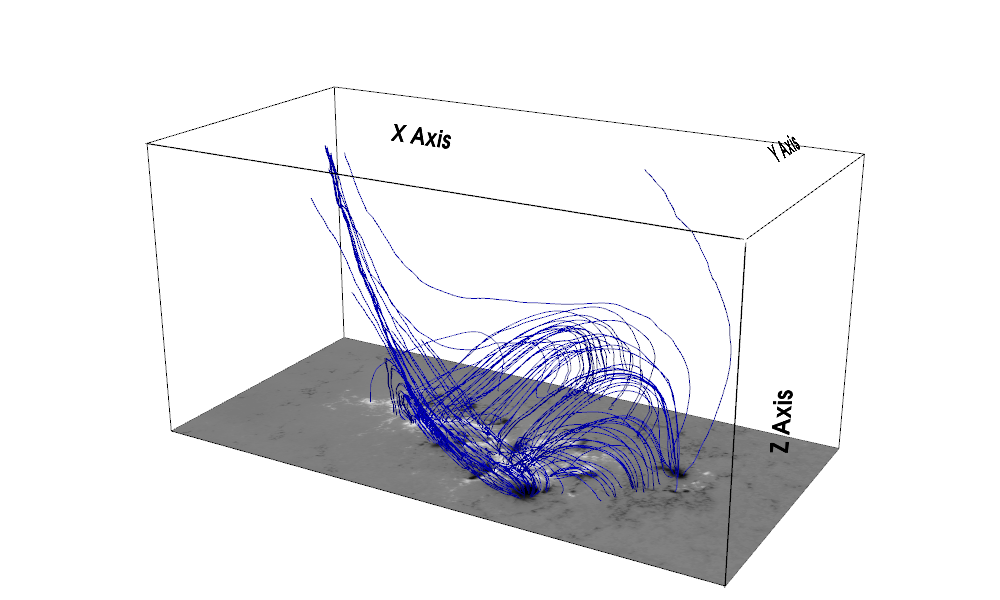

/workspaces/template_pytorch/.venv/lib/python3.12/site-packages/pyvista/core/utilities/points.py:77: UserWarning: Points is not a float type. This can cause issues when transforming or applying filters. Casting to ``np.float32``. Disable this by passing ``force_float=False``.
  warnings.warn(
/workspaces/template_pytorch/.venv/lib/python3.12/site-packages/pyvista/core/filters/data_set.py:3066: PyVistaDeprecationWarning: ``max_time`` parameter is deprecated.  It will be removed in v0.48
  warnings.warn(


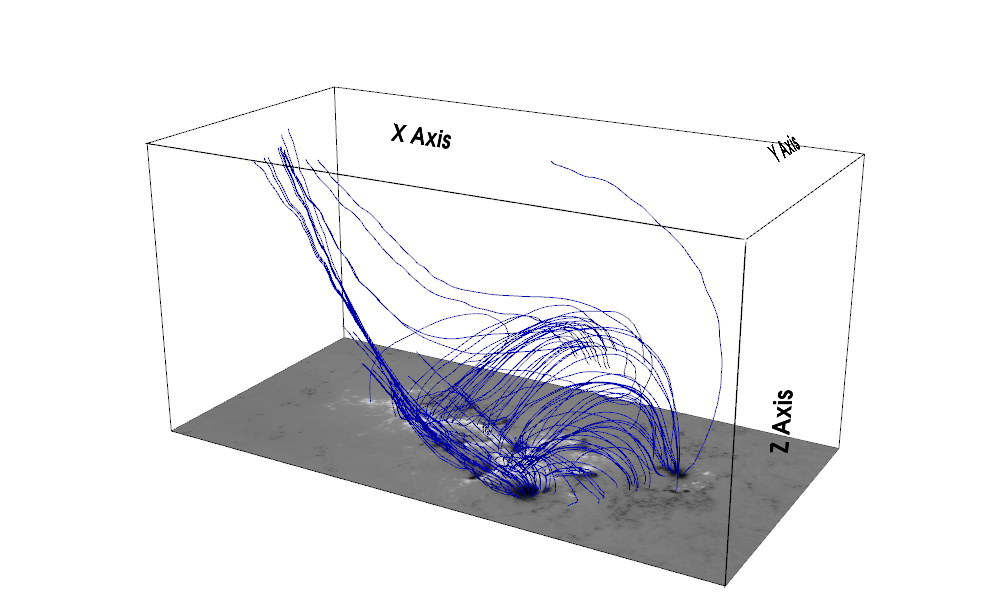

/workspaces/template_pytorch/.venv/lib/python3.12/site-packages/pyvista/core/utilities/points.py:77: UserWarning: Points is not a float type. This can cause issues when transforming or applying filters. Casting to ``np.float32``. Disable this by passing ``force_float=False``.
  warnings.warn(
/workspaces/template_pytorch/.venv/lib/python3.12/site-packages/pyvista/core/filters/data_set.py:3066: PyVistaDeprecationWarning: ``max_time`` parameter is deprecated.  It will be removed in v0.48
  warnings.warn(


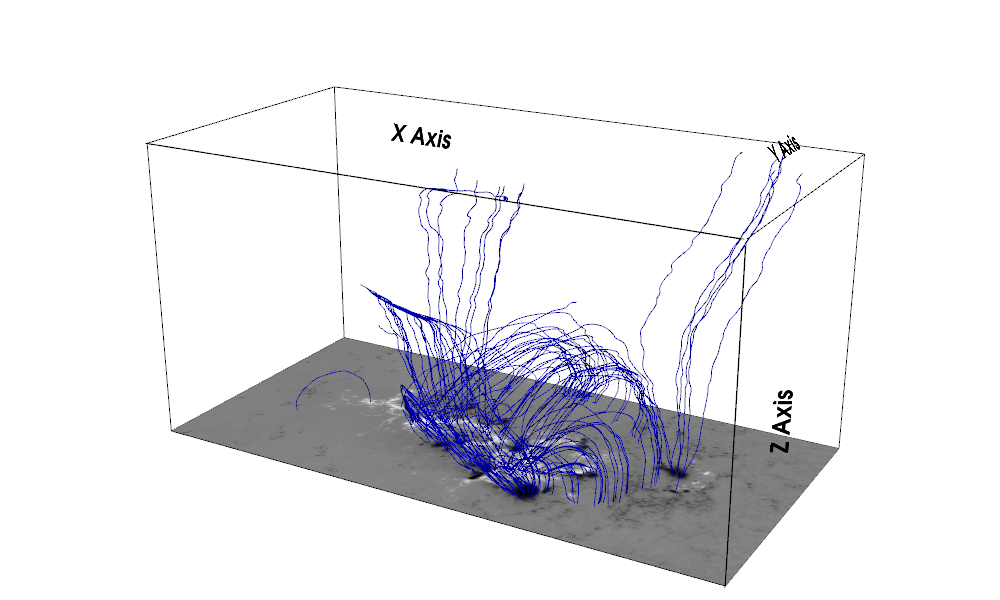

/workspaces/template_pytorch/.venv/lib/python3.12/site-packages/pyvista/core/utilities/points.py:77: UserWarning: Points is not a float type. This can cause issues when transforming or applying filters. Casting to ``np.float32``. Disable this by passing ``force_float=False``.
  warnings.warn(
/workspaces/template_pytorch/.venv/lib/python3.12/site-packages/pyvista/core/filters/data_set.py:3066: PyVistaDeprecationWarning: ``max_time`` parameter is deprecated.  It will be removed in v0.48
  warnings.warn(


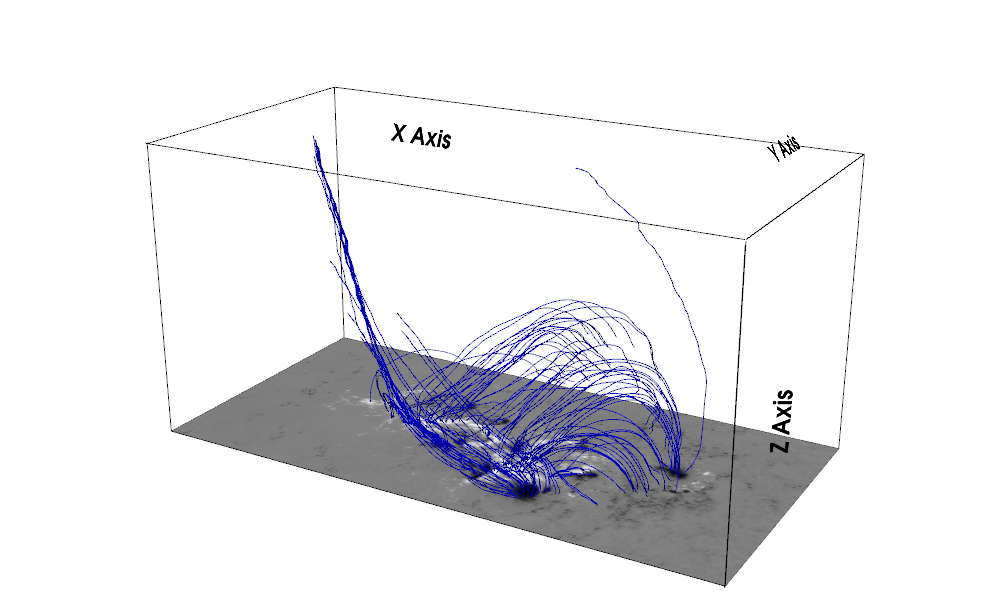

/workspaces/template_pytorch/.venv/lib/python3.12/site-packages/pyvista/core/utilities/points.py:77: UserWarning: Points is not a float type. This can cause issues when transforming or applying filters. Casting to ``np.float32``. Disable this by passing ``force_float=False``.
  warnings.warn(
/workspaces/template_pytorch/.venv/lib/python3.12/site-packages/pyvista/core/filters/data_set.py:3066: PyVistaDeprecationWarning: ``max_time`` parameter is deprecated.  It will be removed in v0.48
  warnings.warn(


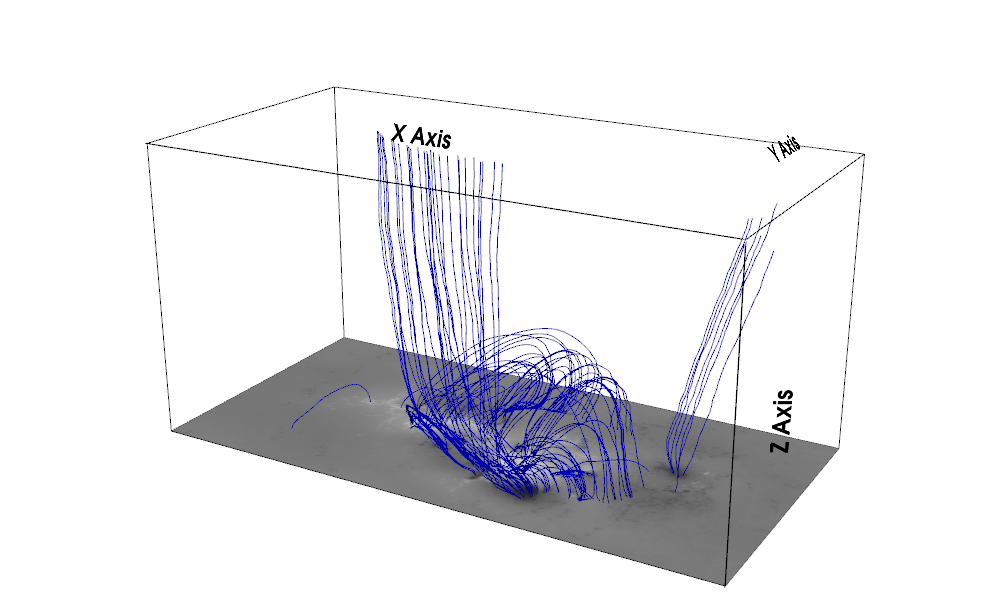

/workspaces/template_pytorch/.venv/lib/python3.12/site-packages/pyvista/core/utilities/points.py:77: UserWarning: Points is not a float type. This can cause issues when transforming or applying filters. Casting to ``np.float32``. Disable this by passing ``force_float=False``.
  warnings.warn(
/workspaces/template_pytorch/.venv/lib/python3.12/site-packages/pyvista/core/filters/data_set.py:3066: PyVistaDeprecationWarning: ``max_time`` parameter is deprecated.  It will be removed in v0.48
  warnings.warn(


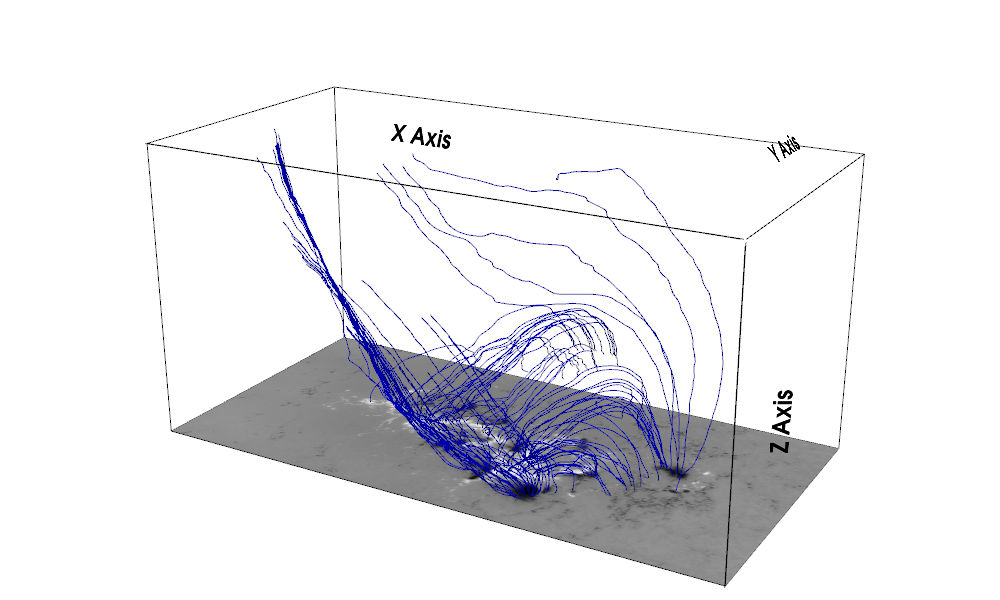

/workspaces/template_pytorch/.venv/lib/python3.12/site-packages/pyvista/core/utilities/points.py:77: UserWarning: Points is not a float type. This can cause issues when transforming or applying filters. Casting to ``np.float32``. Disable this by passing ``force_float=False``.
  warnings.warn(
/workspaces/template_pytorch/.venv/lib/python3.12/site-packages/pyvista/core/filters/data_set.py:3066: PyVistaDeprecationWarning: ``max_time`` parameter is deprecated.  It will be removed in v0.48
  warnings.warn(


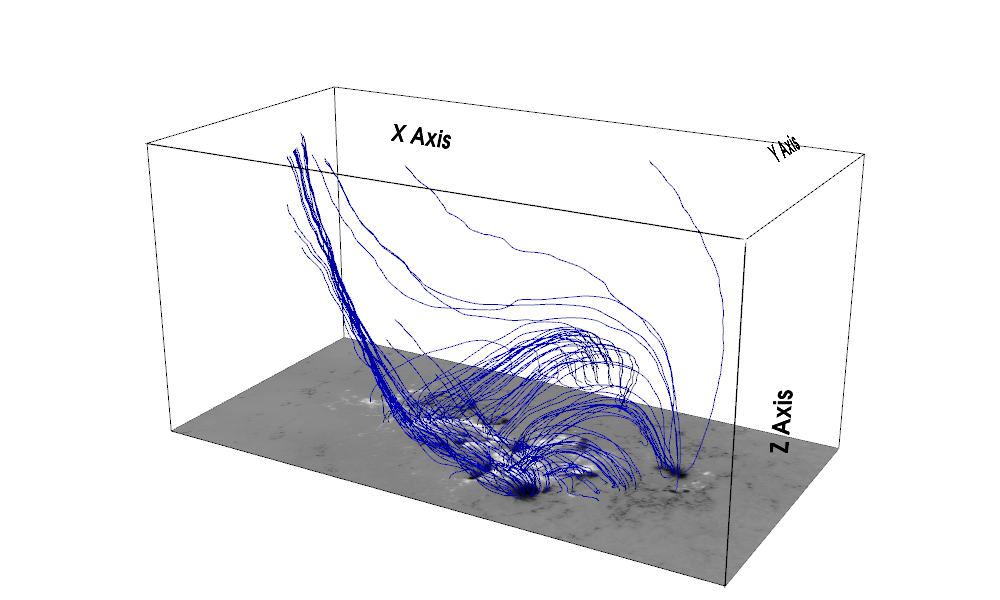

/workspaces/template_pytorch/.venv/lib/python3.12/site-packages/pyvista/core/utilities/points.py:77: UserWarning: Points is not a float type. This can cause issues when transforming or applying filters. Casting to ``np.float32``. Disable this by passing ``force_float=False``.
  warnings.warn(
/workspaces/template_pytorch/.venv/lib/python3.12/site-packages/pyvista/core/filters/data_set.py:3066: PyVistaDeprecationWarning: ``max_time`` parameter is deprecated.  It will be removed in v0.48
  warnings.warn(


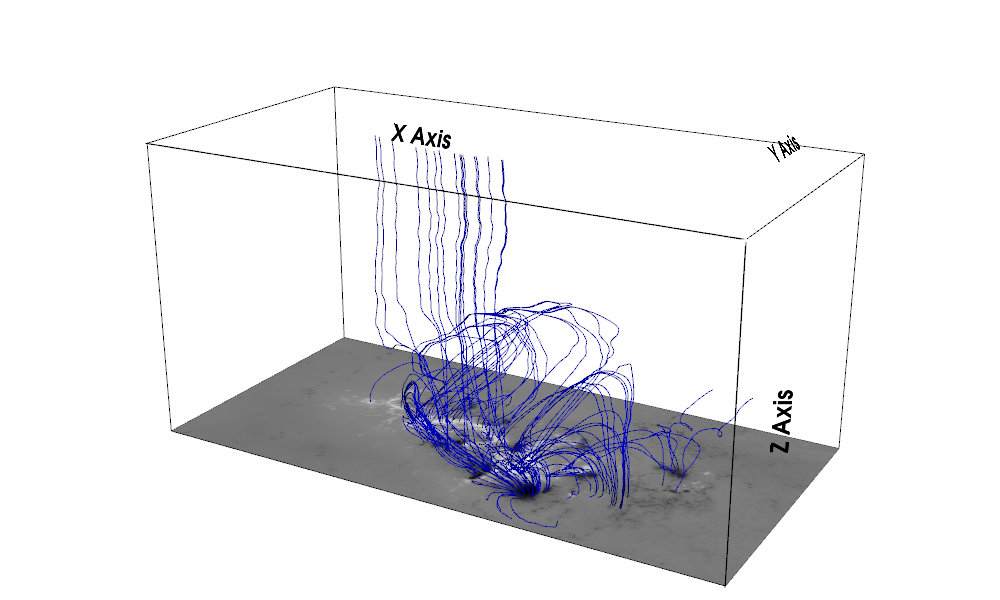

In [ ]:
import pyvista as pv
from scipy.ndimage import zoom

# z方向だけ拡大 (64 -> 256)
for i in range(len(b_array)):
    b_resampled = zoom(b_array[i], (1, 1, 256/64, 1), order=1)
    nx, ny, nz, _ = b_resampled.shape
    x = np.arange(nx)
    y = np.arange(ny)
    z = np.arange(nz)

    xv, yv, zv = np.meshgrid(x, y, z, indexing='ij')
    mesh = pv.StructuredGrid(xv, yv, zv)

    bx, by, bz = b_resampled[..., 0], b_resampled[..., 1], b_resampled[..., 2]
    vectors = np.stack([bx, by, bz], axis=-1).transpose(2, 1, 0, 3).reshape(-1, 3)

    mesh["vector"] = vectors
    mesh.active_vectors_name = "vector"

    xx, yy = np.meshgrid(x, y, indexing='ij')
    seeds_xs = np.stack([xx[seeds[:, 0], seeds[:, 1]], 
                        yy[seeds[:, 0], seeds[:, 1]], 
                        np.zeros_like(seeds[:, 0])], axis=1)
    seeds_xs.shape
    pv.global_theme.notebook = True
    pv.global_theme.jupyter_backend = 'static'
    # pv.global_theme.jupyter_backend = 'trame'
    p = pv.Plotter(window_size=(1000, 600))

    p.show_bounds(
        grid='front',
        show_xlabels=False,
        show_ylabels=False,
        show_zlabels=False,
    )
    p.add_mesh(mesh.outline(), color='k')

    seed = pv.PolyData(seeds_xs)
    strl = mesh.streamlines_from_source(seed, vectors='vector', integration_direction='both',
                                        max_time=10000, initial_step_length=0.1)
    p.add_mesh(strl.tube(radius=0.4), color='blue')

    bottom_subset = mesh.extract_subset((0, nx-1, 0, ny-1, 0, 0)).extract_surface()
    p.add_mesh(bottom_subset, cmap='gray', scalars='vector', component=2, clim=(-2000, 2000), 
            lighting=False, show_scalar_bar=False)

    p.camera_position = "xy"
    p.camera.roll = -30
    p.camera.elevation = -70
    p.camera.zoom(1.3)
    p.show()

Model loaded from epoch 10
b_norm = 200 G
cuda:0
0.17485690116882324 seconds


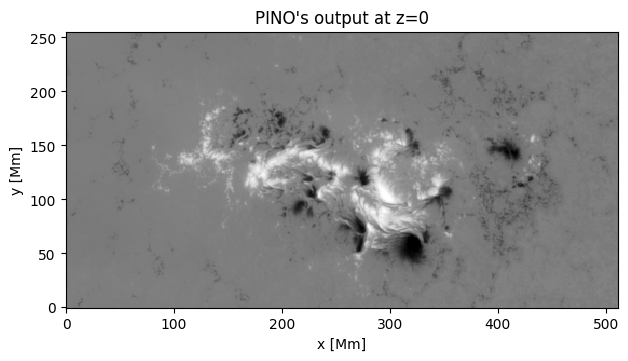

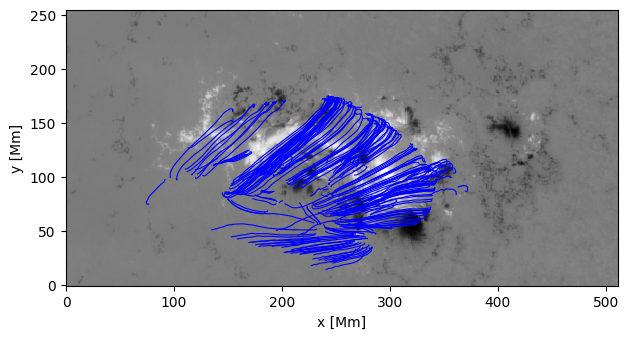

In [ ]:
import torch
from rtmag.process.paper.load import MyModel
import matplotlib.pyplot as plt
import numpy as np
from streamtracer import StreamTracer, VectorGrid

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
#meta_path = "pretrained/isee/best_model.pt"
meta_path = "/workspaces/template_pytorch/rtmag-main/D:/models/lowlou_high_div/best_model.pt"

path = ["/workspaces/template_pytorch/rtmag-main/D:/models/lowlou_high_div/best_model.pt", 
        "/workspaces/template_pytorch/rtmag-main/D:/models/lowlou_high_ff/model_5.pt", 
        "/workspaces/template_pytorch/rtmag-main/D:/models/lowlou_low_div/best_model.pt",
        "/workspaces/template_pytorch/rtmag-main/D:/models/lowlou_low_ff/model_5.pt",
        "/workspaces/template_pytorch/rtmag-main/D:/models/lowlou_no_bc/model_5.pt",
        "/workspaces/template_pytorch/rtmag-main/D:/models/lowlou_no_div/model_4.pt",
        "/workspaces/template_pytorch/rtmag-main/D:/models/lowlou_no_ff/model_4.pt",

        ]

mm = MyModel(meta_path, device=device)

b = mm.get_pred_from_numpy(model_input)
b.shape

bottom = b[:, :, 0, 2]
mask = np.abs(bottom) > 1000#z方向磁場で強い所を抽出

fig, ax = plt.subplots()
ax.pcolormesh(x, y, bottom.T, cmap='gray', vmin=-2000, vmax=2000)
ax.set_xlabel('x [Mm]')
ax.set_ylabel('y [Mm]')
ax.set_aspect('equal')
ax.set_title("PINO's output at z=0")
plt.tight_layout()
plt.show()


stride = 20#流線を作成
seeds = np.stack([np.where(mask == True)[0], 
                  np.where(mask == True)[1], 
                  np.zeros_like(np.where(mask == True)[0])], axis=1)
seeds = seeds[::stride]
seeds.shape

nsteps = 10000
step_size = 0.1
grid_spacing = [1, 1, 1]

grid = VectorGrid(b.astype(np.float64), grid_spacing)
tracer = StreamTracer(nsteps, step_size)
tracer_xs = []
tracer.trace(seeds, grid)
tracer_xs.append(tracer.xs)
tracer_xs = [item for sublist in tracer_xs for item in sublist]

fig, ax = plt.subplots()
ax.pcolormesh(x, y, bottom.T, cmap='gray', vmin=-2000, vmax=2000)
ax.set_xlabel('x [Mm]')
ax.set_ylabel('y [Mm]')
ax.set_aspect('equal')
for i, xl in enumerate(tracer_xs):
    assert seeds[i] in xl 
    ax.plot(xl[:,0]*dx+x[0], xl[:,1]*dy+y[0], color='blue', linewidth=0.8)
plt.tight_layout()
plt.show()


/workspaces/template_pytorch/.venv/lib/python3.12/site-packages/pyvista/core/utilities/points.py:77: UserWarning: Points is not a float type. This can cause issues when transforming or applying filters. Casting to ``np.float32``. Disable this by passing ``force_float=False``.
  warnings.warn(
/workspaces/template_pytorch/.venv/lib/python3.12/site-packages/pyvista/core/filters/data_set.py:3066: PyVistaDeprecationWarning: ``max_time`` parameter is deprecated.  It will be removed in v0.48
  warnings.warn(


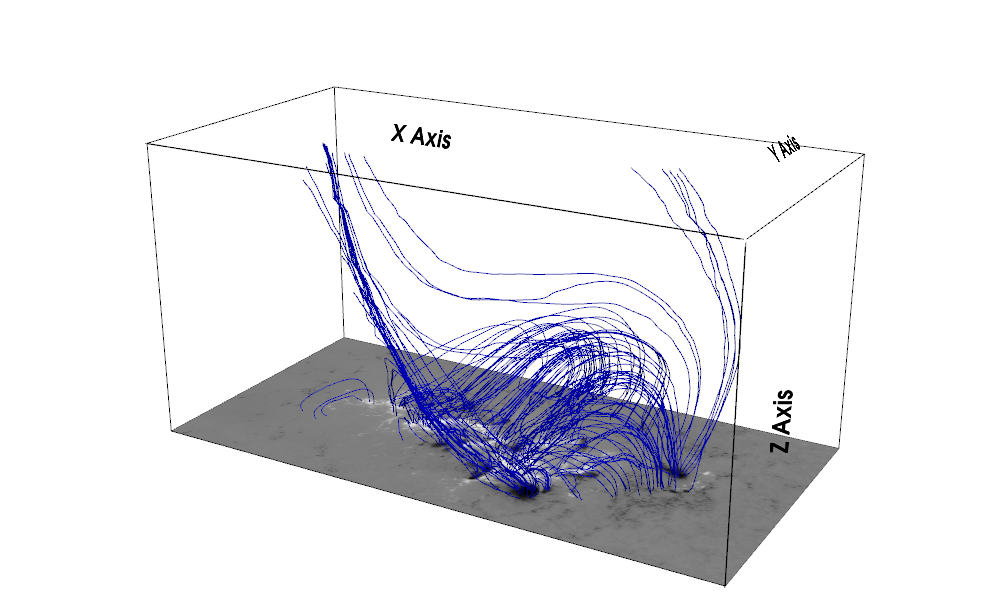

In [ ]:
import pyvista as pv
from scipy.ndimage import zoom

# z方向だけ拡大 (64 -> 256)
b_resampled = zoom(b, (1, 1, 256/64, 1), order=1)
nx, ny, nz, _ = b_resampled.shape
x = np.arange(nx)
y = np.arange(ny)
z = np.arange(nz)

xv, yv, zv = np.meshgrid(x, y, z, indexing='ij')
mesh = pv.StructuredGrid(xv, yv, zv)

bx, by, bz = b_resampled[..., 0], b_resampled[..., 1], b_resampled[..., 2]
vectors = np.stack([bx, by, bz], axis=-1).transpose(2, 1, 0, 3).reshape(-1, 3)

mesh["vector"] = vectors
mesh.active_vectors_name = "vector"

xx, yy = np.meshgrid(x, y, indexing='ij')
seeds_xs = np.stack([xx[seeds[:, 0], seeds[:, 1]], 
                     yy[seeds[:, 0], seeds[:, 1]], 
                     np.zeros_like(seeds[:, 0])], axis=1)
seeds_xs.shape
pv.global_theme.notebook = True
pv.global_theme.jupyter_backend = 'static'
# pv.global_theme.jupyter_backend = 'trame'
p = pv.Plotter(window_size=(1000, 600))

p.show_bounds(
    grid='front',
    show_xlabels=False,
    show_ylabels=False,
    show_zlabels=False,
)
p.add_mesh(mesh.outline(), color='k')

seed = pv.PolyData(seeds_xs)
strl = mesh.streamlines_from_source(seed, vectors='vector', integration_direction='both',
                                    max_time=10000, initial_step_length=0.1)
p.add_mesh(strl.tube(radius=0.4), color='blue')

bottom_subset = mesh.extract_subset((0, nx-1, 0, ny-1, 0, 0)).extract_surface()
p.add_mesh(bottom_subset, cmap='gray', scalars='vector', component=2, clim=(-2000, 2000), 
           lighting=False, show_scalar_bar=False)

p.camera_position = "xy"
p.camera.roll = -30
p.camera.elevation = -70
p.camera.zoom(1.3)
p.show()